In [1]:
import sys
sys.path.append('../src/')

from cryosim import atom
import matplotlib.pyplot as plt
import mrcfile
from cryosim import pdbtools
from cryosim import potential
import torch
from tqdm import tqdm
from cryosim.plotting_tools import plot3d, plot_slices
from cryosim.potential import PotentialBuilder

%load_ext autoreload
%autoreload 2

## Download PDB file

In [2]:
folder = '../pdb-data/'
filename = pdbtools.fetch_pdb_file("6bdf", output=folder)
filename

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.


'../pdb-data/6bdf-assembly1.cif'

## Extract atomic coordinates and recenter onto (0,0,0)

In [3]:
# extracts raw coordinates for each atom in (x,y,z) order from pdb file
assemble = True
atomic_numbers, coords = pdbtools.get_atoms_and_coordinates_from_pdb(filename)
atomic_numbers.shape, coords.shape

Parsing ../pdb-data/6bdf-assembly1.cif.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

(torch.Size([46382]), torch.Size([46382, 3]))

In [4]:
# elements in particle
print(set(atom.atom_symbol(atomic_numbers)))

{'N', 'C', 'O', 'S'}


In [5]:
coords.shape

torch.Size([46382, 3])

In [6]:
# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

## Convolution method

In [7]:
n = 256
dx = 1
vol_3d, occupancy, atomic_potentials = potential.build_potential_volume_fftconvolve_3d(
    atomic_numbers,
    centered_coords,
    n,
    dx,
)

  0%|          | 0/4 [00:00<?, ?it/s]

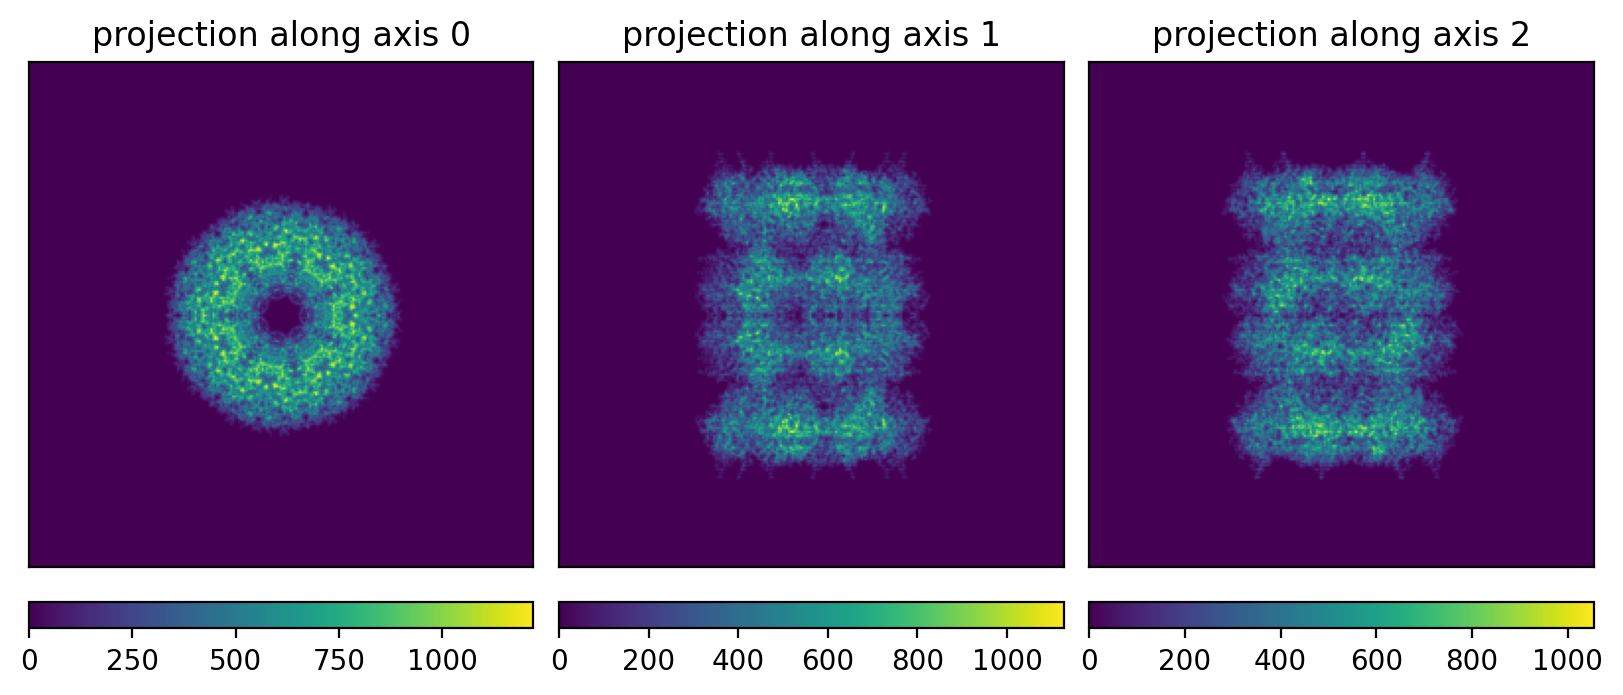

In [8]:
plot3d(vol_3d)

In [9]:
vol_2d, occupancy, atomic_potentials = potential.build_potential_volume_fftconvolve_2d(
    atomic_numbers,
    centered_coords,
    n,
    dx,
)

  0%|          | 0/4 [00:00<?, ?it/s]

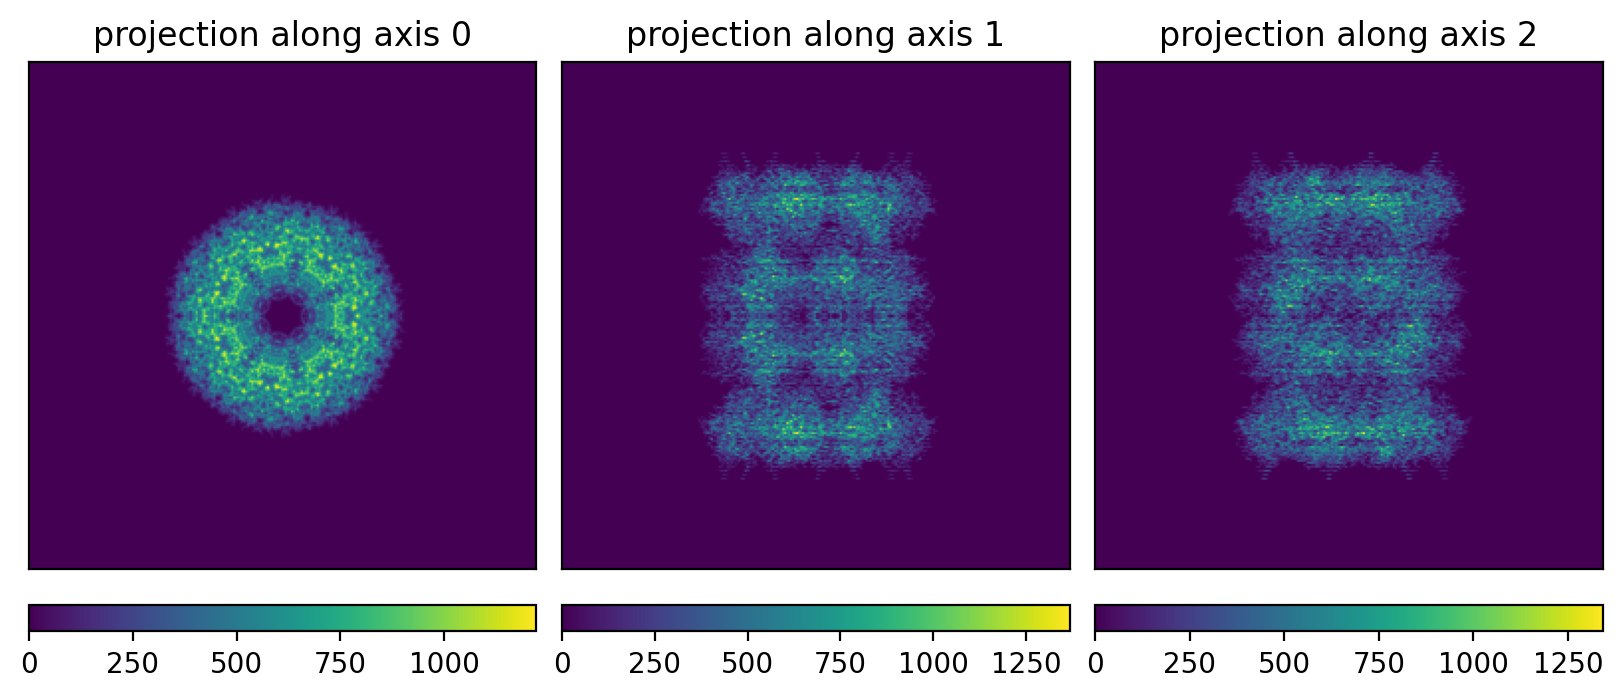

In [10]:
plot3d(vol_2d)

## Compare error between 2D and 3D

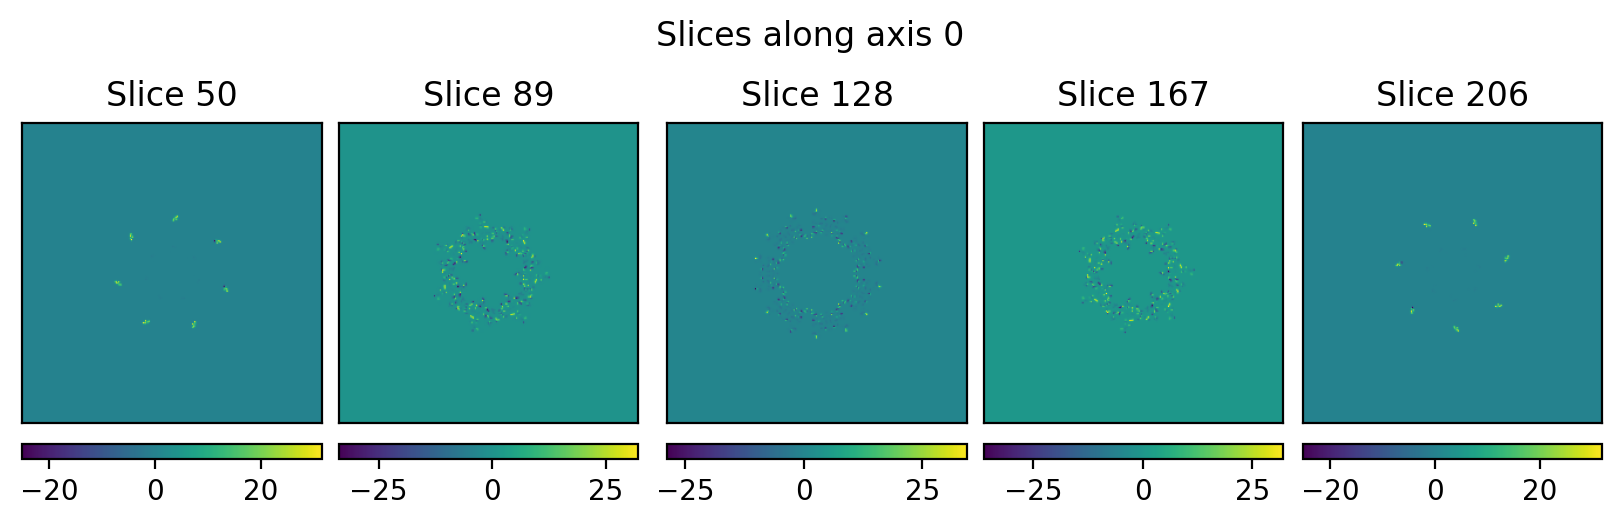

In [11]:
start_idx = 50
plot_slices(vol_2d - vol_3d, start_idx=start_idx, end_idx=n - start_idx)

## PotentialBuilder class

In [12]:
device = 'cuda'
pb = PotentialBuilder(n, dx, atomic_numbers, centered_coords).to(device)

In [13]:
with torch.no_grad():
    vol = pb(method='3d')

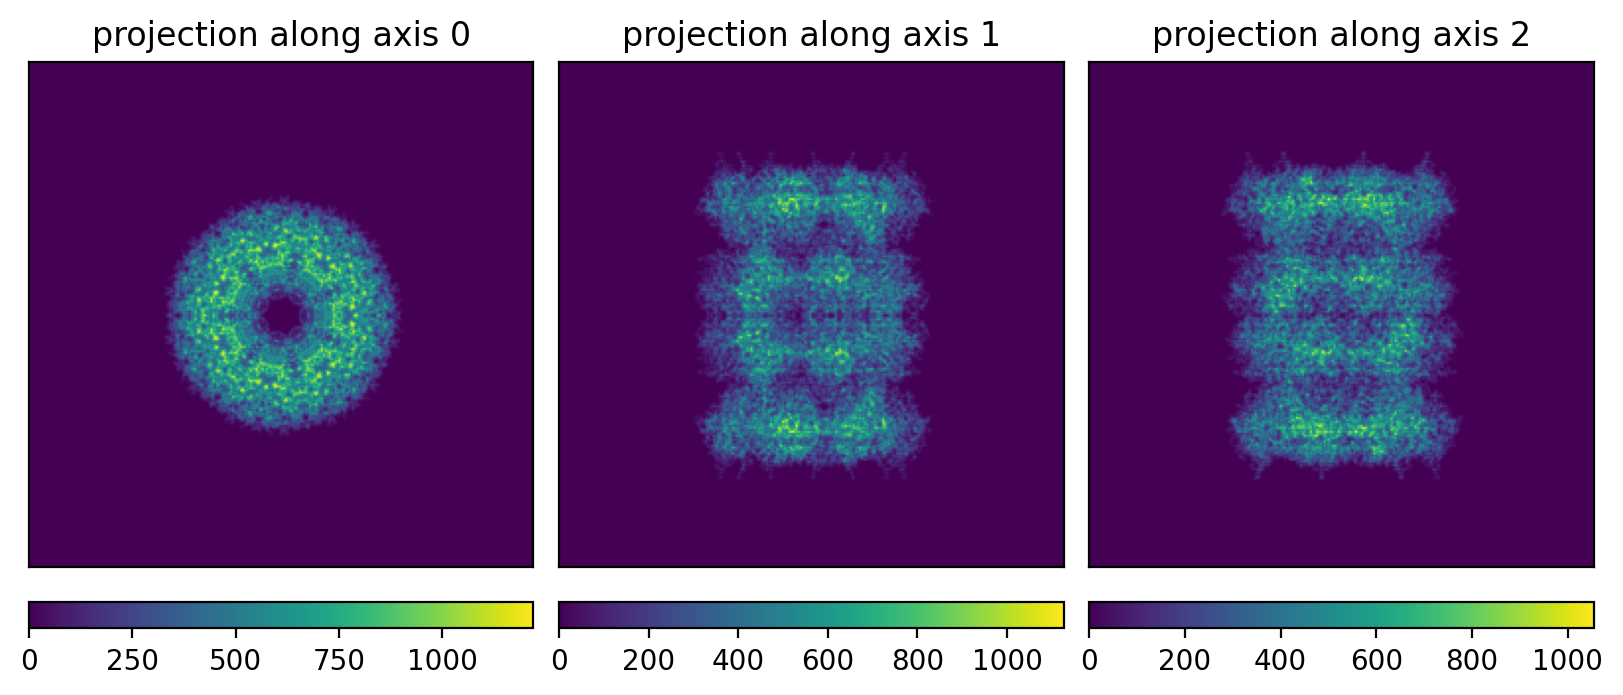

In [14]:
plot3d(vol.detach().cpu())

In [15]:
import torch
from cryosim.rotations import Rotation
from cryosim import rotations
import numpy as np
from scipy.spatial.transform import Rotation as R

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [82]:
quat = rotations.random_quaternion(2)
quat.shape

torch.Size([2, 4])

In [83]:
R = Rotation.from_quat(quat.clone())

In [84]:
test = R.apply(centered_coords, inverse=True)

In [85]:
rm = R.as_matrix()
am = rotations.build_affine_matrix(rm)

In [91]:
i = 1
new_vol = rotations.rotate_volume(vol.detach().cpu().clone(), am[i].unsqueeze(0))
vol_3d, occupancy, atomic_potentials = potential.build_potential_volume_fftconvolve_3d(
    atomic_numbers,
    test[i],
    n,
    dx,
)

  0%|          | 0/4 [00:00<?, ?it/s]

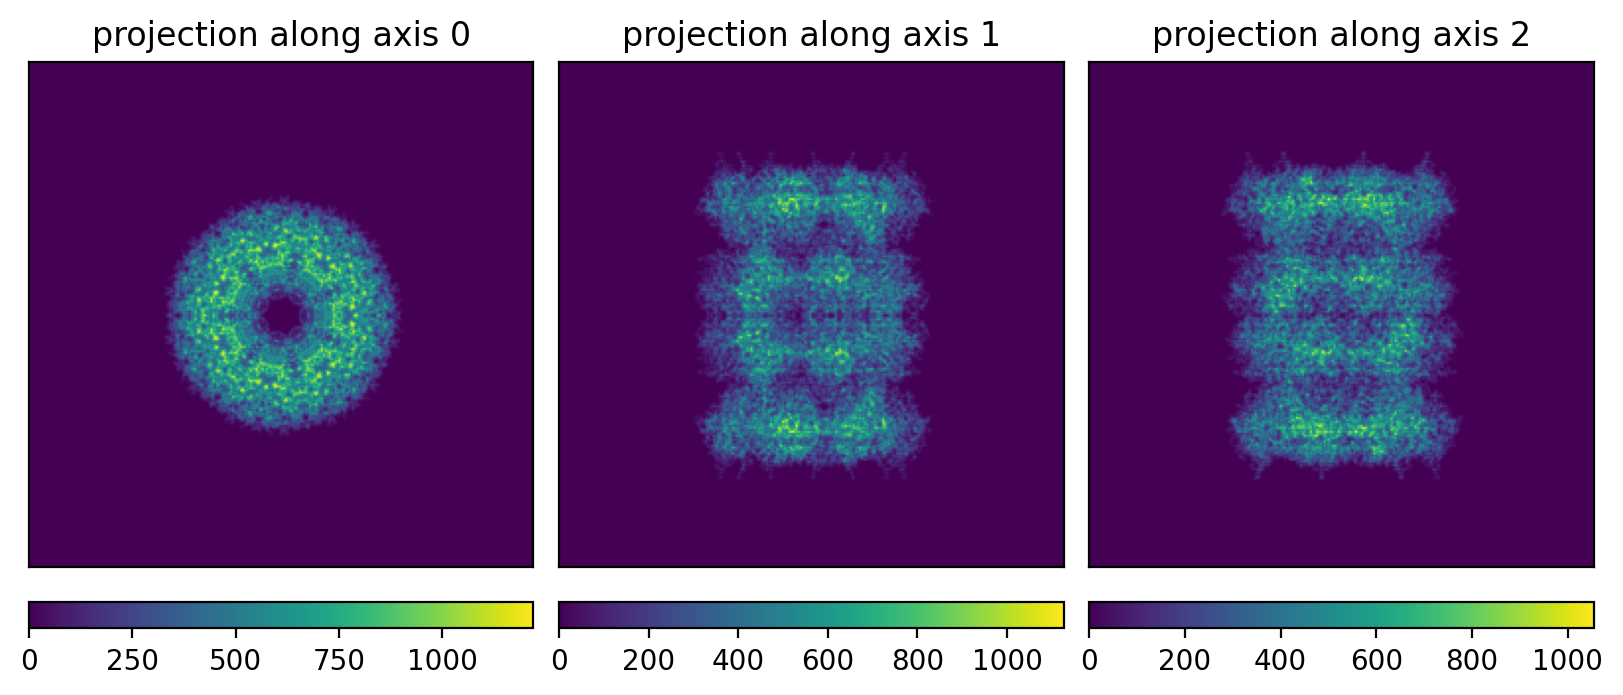

In [92]:
plot3d(vol.detach().cpu())

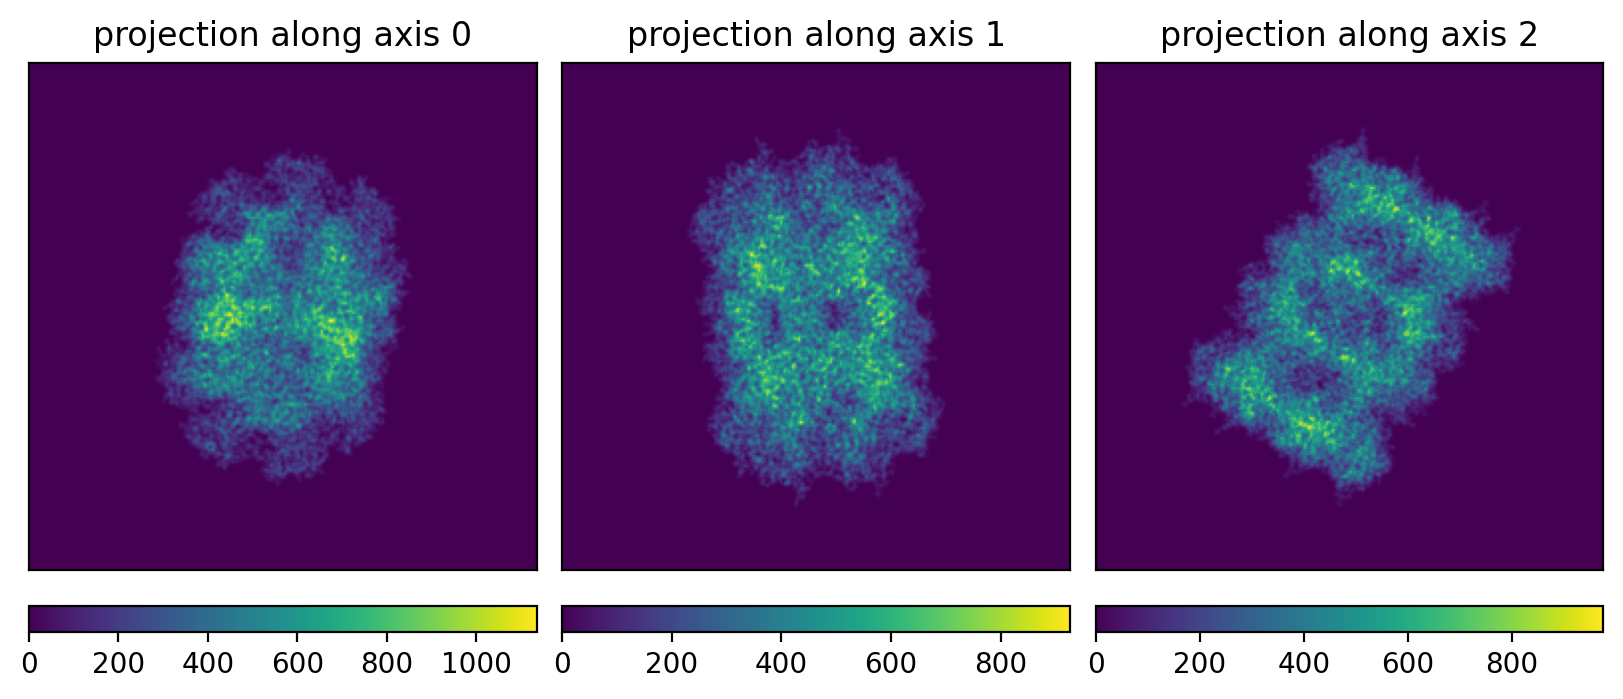

In [93]:
plot3d(new_vol.squeeze())

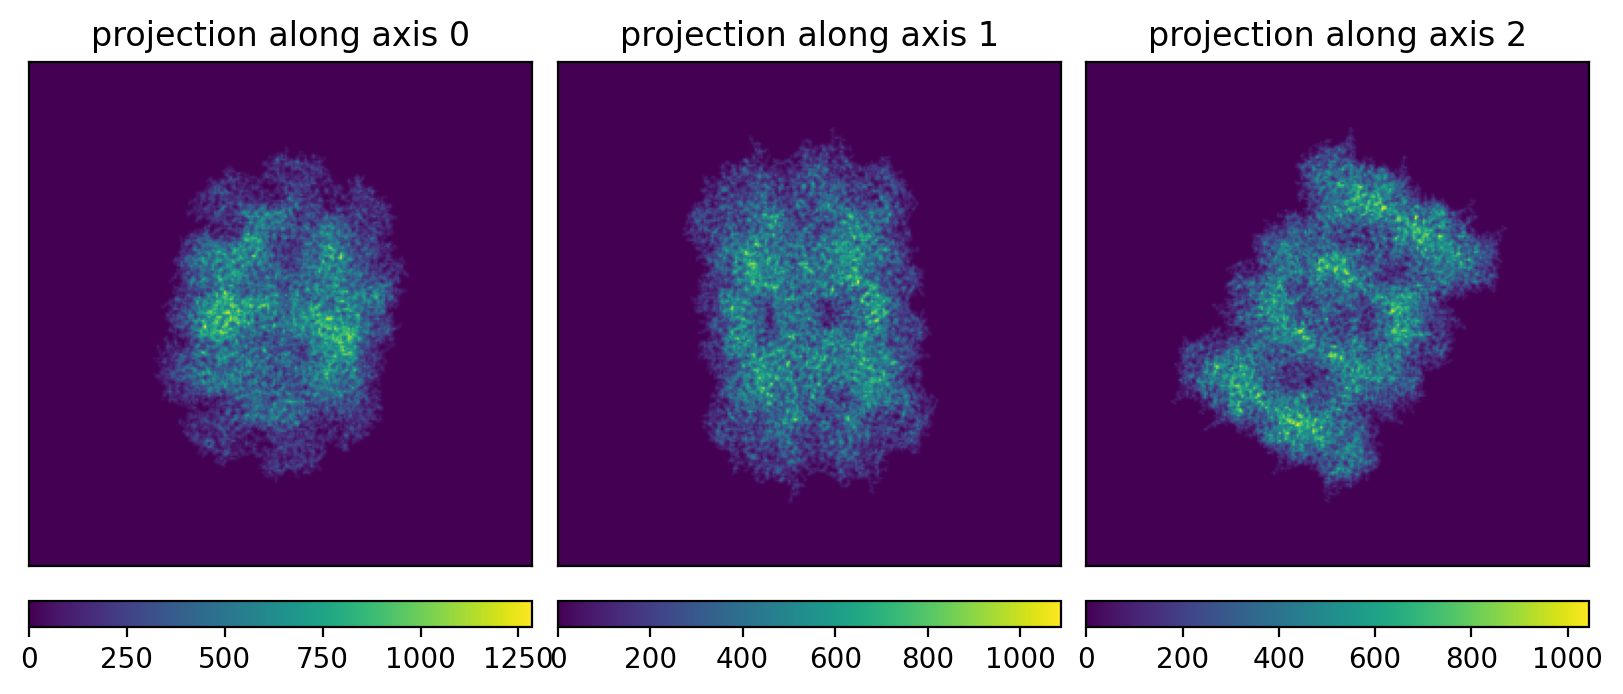

In [94]:
plot3d(vol_3d)